In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ast
import os
from sklearn.preprocessing import OneHotEncoder

## British Columbia Canada

In [167]:
bc = pd.read_csv("canada/british_columbia.csv", low_memory=False)

In [168]:
bc.head(6)

,streetAddress,addressLocality,addressRegion,postalCode,latitude,longitude,description,price,priceCurrency,property-beds,...,MLS Area Minor,View,Foundation Details,SqFt Range,Building Area Source,Buyer Agent Designation,Lot Measurement,Lot Size Source,Topography,Current Financing
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"765 Westpoint Drive, Kelowna, BC V1W2Z4",Kelowna,BC,V1W2Z4,49.821860,-119.480143,"Imagine waking up to serene lake views, surrou...",1298000.0,CAD,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"20514 75 AVENUE, Langley, BC V2Y 1V5",Langley,BC,V2Y 1V5,49.138904,-122.654191,Introducing a brand-new middle unit in highly ...,1399999.0,CAD,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"11679 74 AVENUE, Delta, BC V4C 1E6",Delta,BC,V4C 1E6,49.137724,-122.899288,Take advantage of this incredible opportunity ...,799000.0,CAD,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


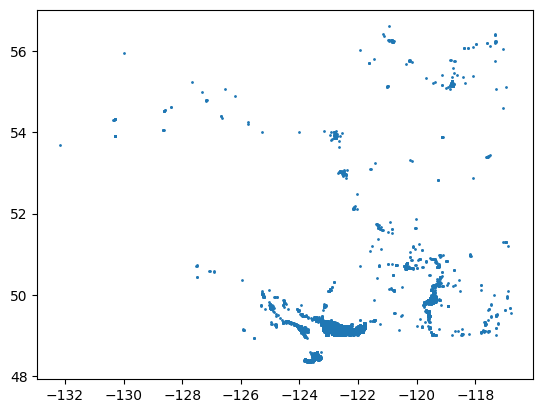

In [169]:
plt.scatter(bc["longitude"], bc["latitude"], s=1)

#### We check how much valid values each columns contains

In [170]:
bc_valid_columns = []
for c in bc.columns:
    if (len(bc) - bc[c].isna().sum(axis=0)) > 100:
        bc_valid_columns.append(c)
        print(f"{c} : {len(bc) - bc[c].isna().sum(axis=0)}")

streetAddress : 24361
addressLocality : 24361
addressRegion : 24358
postalCode : 24347
latitude : 24361
longitude : 24361
description : 24301
price : 24361
priceCurrency : 24361
property-beds : 22970
property-baths : 24342
property-sqft : 22885
Acreage : 11759
Basement : 2418
Bath : 2462
Exterior : 4508
Exterior Features : 4508
Features : 22957
Fireplace : 15671
Garage : 921
Heating : 22888
MLS® # : 24361
Partial Bathroom : 2462
Property Tax : 12186
Property Type : 24361
Roof : 3366
Sewer : 5182
Square Footage : 22934
Subdivision : 19393
Type : 24361
Waterfront : 178
Parking : 22879
Flooring : 4391
Water : 178
Parking Features : 22879
Fireplace Features : 15532
MLS : 24361


We only keep useful columns that will help us to predict the price for a real estate asset

In [171]:
bc_valid_columns = [
    "streetAddress", "addressLocality", "addressRegion", "postalCode", "latitude", "longitude", "price", "property-beds",
    "property-baths", "property-sqft", "Acreage", "Heating", "Property Tax", "Property Type", "Square Footage", "Garage", "Parking"
]

bc = bc[bc_valid_columns]
bc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24382 entries, 0 to 24381
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   streetAddress    24361 non-null  object 
 1   addressLocality  24361 non-null  object 
 2   addressRegion    24358 non-null  object 
 3   postalCode       24347 non-null  object 
 4   latitude         24361 non-null  float64
 5   longitude        24361 non-null  float64
 6   price            24361 non-null  float64
 7   property-beds    22970 non-null  float64
 8   property-baths   24342 non-null  float64
 9   property-sqft    22885 non-null  object 
 10  Acreage          11759 non-null  float64
 11  Heating          22888 non-null  object 
 12  Property Tax     12186 non-null  object 
 13  Property Type    24361 non-null  object 
 14  Square Footage   22934 non-null  object 
 15  Garage           921 non-null    object 
 16  Parking          22879 non-null  object 
dtypes: float64(6

#### Let's see if we only have housing from British Columbia

In [172]:
unique, counts = np.unique(np.array(bc["addressRegion"].dropna()), return_counts=True)

In [173]:
print("Adress regions : ", unique)
print("NB adress regions : ", counts)

Adress regions :  ['AB' 'BC' 'NL' 'ON']
NB adress regions :  [  131 24221     4     2]


The data is mixed with some data from other provinces. We'll keep those from British-Columbia 'BC'

In [174]:
bc = bc[bc["addressRegion"] == "BC"]
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24221 entries, 3 to 24381
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   streetAddress    24221 non-null  object 
 1   addressLocality  24221 non-null  object 
 2   addressRegion    24221 non-null  object 
 3   postalCode       24208 non-null  object 
 4   latitude         24221 non-null  float64
 5   longitude        24221 non-null  float64
 6   price            24221 non-null  float64
 7   property-beds    22834 non-null  float64
 8   property-baths   24188 non-null  float64
 9   property-sqft    22775 non-null  object 
 10  Acreage          11638 non-null  float64
 11  Heating          22770 non-null  object 
 12  Property Tax     12150 non-null  object 
 13  Property Type    24221 non-null  object 
 14  Square Footage   22824 non-null  object 
 15  Garage           877 non-null    object 
 16  Parking          22763 non-null  object 
dtypes: float64(6), ob

In [175]:
bc_valid_columns = [
    "latitude", "longitude", "price", "property-beds",
    "property-baths", "Acreage", "Heating", "Property Tax", "Property Type", "Square Footage", "Garage", "Parking"
]

In [176]:
bc = bc[bc_valid_columns]
bc.head(3)

,latitude,longitude,price,property-beds,property-baths,Acreage,Heating,Property Tax,Property Type,Square Footage,Garage,Parking
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Forced air,"$6,995",Single Family,"4,374 SQFT",NaN,Attached Garage
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,Forced Air,"$2,585 (2024)",Duplex,"2,404 SQFT",NaN,DetachedGrge/Carport
5,49.137724,-122.899288,799000.0,NaN,0.0,0.09,NaN,"$4,252 (2024)",Vacant Land,NaN,NaN,NaN


#### Let's make sure that we only have housings and not other types in the `Property Type` feature

In [177]:
u_type, c_type = np.unique(bc["Property Type"].dropna(), return_counts=True)

In [178]:
print(f"Types of real estate asset : {u_type}")
print(f"Number of each : {c_type}")

Types of real estate asset : ['Agricultural' 'Condo' 'Condo/Townhome' 'Duplex' 'Manufactured Home'
 'Mobile Home' 'MultiFamily' 'Single Family' 'Timeshare' 'Townhome'
 'Vacant Land']
Number of each : [  26 9027 1057  575  196    5  205 9938    1 1963 1228]


I'll remove the values {`'Agricultural'`, `'Mobile Home'`, `'Timeshare'`,`'Vacant Land'`} because they represent a small amount of data among all our dataset and they aren't the main real estate assets that we want to predict, so they'll bring noise to our predictions.

In [179]:
bc = bc[~bc["Property Type"].isin(['Agricultural', 'Mobile Home', 'Timeshare','Vacant Land'])]
bc["Property Type"].unique()

array(['Single Family', 'Duplex', 'Condo', 'Townhome', 'Condo/Townhome',
       'MultiFamily', 'Manufactured Home'], dtype=object)

#### Let's remove rows that contains missing data for the following features : `property-beds`, `property-baths`, `price`, `Square Footage`

In [180]:
bc = bc[~ bc["property-beds"].isna()]
bc = bc[~ bc["property-baths"].isna()]
bc = bc[~bc["Square Footage"].isna()]

In [181]:
bc.head(3)

,latitude,longitude,price,property-beds,property-baths,Acreage,Heating,Property Tax,Property Type,Square Footage,Garage,Parking
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Forced air,"$6,995",Single Family,"4,374 SQFT",NaN,Attached Garage
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,Forced Air,"$2,585 (2024)",Duplex,"2,404 SQFT",NaN,DetachedGrge/Carport
6,49.103726,-122.663125,399900.0,1.0,1.0,NaN,"Baseboard, Electric, Natural Gas","$1,474 (2024)",Condo,632 SQFT,NaN,Garage; Underground


In [182]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22548 entries, 3 to 24381
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        22548 non-null  float64
 1   longitude       22548 non-null  float64
 2   price           22548 non-null  float64
 3   property-beds   22548 non-null  float64
 4   property-baths  22548 non-null  float64
 5   Acreage         10065 non-null  float64
 6   Heating         22523 non-null  object 
 7   Property Tax    11594 non-null  object 
 8   Property Type   22548 non-null  object 
 9   Square Footage  22548 non-null  object 
 10  Garage          861 non-null    object 
 11  Parking         22253 non-null  object 
dtypes: float64(6), object(6)
memory usage: 2.2+ MB


#### We'll also remove the missing values for the feature `Heating` because there are only 25 missing values.

In [183]:
bc = bc[bc["Heating"].notna()]

In [184]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        22523 non-null  float64
 1   longitude       22523 non-null  float64
 2   price           22523 non-null  float64
 3   property-beds   22523 non-null  float64
 4   property-baths  22523 non-null  float64
 5   Acreage         10048 non-null  float64
 6   Heating         22523 non-null  object 
 7   Property Tax    11582 non-null  object 
 8   Property Type   22523 non-null  object 
 9   Square Footage  22523 non-null  object 
 10  Garage          861 non-null    object 
 11  Parking         22238 non-null  object 
dtypes: float64(6), object(6)
memory usage: 2.2+ MB


#### Now we are going to deal with the features `Acreage`, `Property Tax`, `Parking` and `Garage`.

In [185]:
u_acr, c_acr = np.unique(bc[bc["Acreage"].isna()]["Property Type"], return_counts=True)
print(f"Types of real estate asset : {u_acr}")
print(f"Number of each : {c_acr}")

Types of real estate asset : ['Condo' 'Condo/Townhome' 'Duplex' 'Manufactured Home' 'MultiFamily'
 'Single Family' 'Townhome']
Number of each : [8996 1053  177  136   10  321 1782]


In [186]:
bc[bc["Acreage"].notna() & (bc["Property Type"] == "MultiFamily")]

,latitude,longitude,price,property-beds,property-baths,Acreage,Heating,Property Tax,Property Type,Square Footage,Garage,Parking
92,52.975050,-122.506589,329900.0,4.0,2.0,0.09,"Forced air, Natural gas","$2,819",MultiFamily,"1,740 SQFT",NaN,Open
139,53.894242,-122.753643,599900.0,8.0,6.0,0.16,Natural gas,"$5,975",MultiFamily,"4,070 SQFT",NaN,Carport
1926,49.236447,-122.845606,1938000.0,12.0,4.0,0.18,Forced Air,"$4,899 (2023)",MultiFamily,"4,000 SQFT",NaN,"Add. Parking Avail., Carport; Multiple"
3113,53.900799,-122.754607,549900.0,10.0,4.0,0.13,"Forced air, Natural gas","$4,270",MultiFamily,"3,520 SQFT",NaN,"Carport, Open"
3778,49.265180,-123.173634,2099900.0,5.0,5.0,0.06,"Hot Water, Natural Gas","$6,334 (2024)",MultiFamily,"2,820 SQFT",NaN,Open
...,...,...,...,...,...,...,...,...,...,...,...,...
22798,49.140288,-122.654811,1368000.0,4.0,4.0,0.04,"[""Forced Air""]",NaN,MultiFamily,"2,311 SQFT",NaN,"[""Add. Parking Avail."", ""Garage; Single""]"
23631,49.265070,-123.158304,3990000.0,4.0,3.0,0.14,"[""Forced Air""]",NaN,MultiFamily,"2,412 SQFT",NaN,"[""Open""]"
23632,49.265074,-123.158514,4500000.0,12.0,5.0,0.14,"[""Forced Air""]",NaN,MultiFamily,"4,130 SQFT",NaN,"[""None""]"
23654,49.266408,-123.158194,3299000.0,6.0,4.0,0.13,"[""Baseboard"", ""Electric""]",NaN,MultiFamily,"3,423 SQFT",NaN,"[""Carport; Multiple""]"


#### There are several issues with some features :  
1. There are missing data.
2. In the feature `Parking`, there are either informations about the house parking lot or a missing value. There's no property that indicates the lack of parking or garage in the house.
 
    **Solution** : I'll use an imputation technique which consists to create a new binary feature that indicates the presence of a value. If there's a missing value in a feature, the row that has this missing value will take the value $1$ in the column that serves as a presence indicator. Otherwise it'll take the value $0$.
  
>  Another solution is to train a Machine Learning model on the dataset without the features that contain missing values and train another ML model on the dataset with all the features but without the missing values.  
  By doing this, if a user doesn't have a parking or doesn't know if a property has a parking, he can receive a prediction from the ML model, that has been trained on a dataset that doesn't contain the feature "parking". 
  But this solution isn't the best because we should train ML models on each combination of dataset if there are multiple features that only have either a value from a binary choice or a missing value.

3. The features `Garage` and `parking` have either the value indicating the presence of a garage or nothing. There are no rows containing the value `No` for the parking. All the properties have either a parking or a missing value instead.
4. The values inside the features `Parking` and `Heating` are either an 'str' representation of a list of keywords or an str representation of keywords separated by a coma. We would like to put those keywords into real lists in order to make it easier to create new columns (binary columns).

#### 1/ Imputation of missing values in `Acreage` and `Property Tax`.

In [187]:
bc["Missing Acreage"] = bc["Acreage"].isna().astype(int)

In [188]:
bc["Acreage"] = bc["Acreage"].fillna(0)

> A row with a missing value in a certain feature X, will take the value 1 in the column that serves as presence detection for this feature X.

In [189]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   latitude         22523 non-null  float64
 1   longitude        22523 non-null  float64
 2   price            22523 non-null  float64
 3   property-beds    22523 non-null  float64
 4   property-baths   22523 non-null  float64
 5   Acreage          22523 non-null  float64
 6   Heating          22523 non-null  object 
 7   Property Tax     11582 non-null  object 
 8   Property Type    22523 non-null  object 
 9   Square Footage   22523 non-null  object 
 10  Garage           861 non-null    object 
 11  Parking          22238 non-null  object 
 12  Missing Acreage  22523 non-null  int64  
dtypes: float64(6), int64(1), object(6)
memory usage: 2.4+ MB


In [190]:
bc["Missing Property Tax"] = bc["Property Tax"].isna().astype(int)

In [191]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   latitude              22523 non-null  float64
 1   longitude             22523 non-null  float64
 2   price                 22523 non-null  float64
 3   property-beds         22523 non-null  float64
 4   property-baths        22523 non-null  float64
 5   Acreage               22523 non-null  float64
 6   Heating               22523 non-null  object 
 7   Property Tax          11582 non-null  object 
 8   Property Type         22523 non-null  object 
 9   Square Footage        22523 non-null  object 
 10  Garage                861 non-null    object 
 11  Parking               22238 non-null  object 
 12  Missing Acreage       22523 non-null  int64  
 13  Missing Property Tax  22523 non-null  int64  
dtypes: float64(6), int64(2), object(6)
memory usage: 2.6+ MB


By the way I'll drop the feature `Garage` due to the lack of data

In [192]:
bc[(bc["Garage"] == "Yes") & (bc["Parking"].notna() == False)]

,latitude,longitude,price,property-beds,property-baths,Acreage,Heating,Property Tax,Property Type,Square Footage,Garage,Parking,Missing Acreage,Missing Property Tax


In [193]:
bc = bc.drop(["Garage"], axis=1)

There's no row that contains `Garage = Yes` and `Parking == NaN` at the same time, so we'll remove the feature `Garage`. **Note :** the feature `Garage` is almost empty, compared to the lenght of our dataset, and can be replaced by the informations that we'll extract from the feature `Parking`.

#### Let's fix the feature `Parking`
#### We'll extract the informations from the feature `Parking`. It's a gold mine of information about parking lots and garages.

In [194]:
list(bc["Parking"].unique())

['Attached Garage',
 'DetachedGrge/Carport',
 'Garage; Underground',
 'Driveway, Garage Double, RV Access/Parking',
 'Garage; Single, RV Parking Avail., Tandem Parking',
 'Visitor Parking',
 'Additional Parking, Driveway, Garage',
 'Garage; Double',
 'Driveway, On Street, Open, Other',
 'Garage Underbuilding, Garage; Underground, Visitor Parking',
 'Open, Visitor Parking',
 'Grge/Double Tandem, Visitor Parking',
 'Garage; Triple',
 'Additional Parking, On Street',
 'Additional Parking, Driveway',
 'Add. Parking Avail., Garage; Single',
 nan,
 'Attached Garage, Oversize, See Remarks',
 'Underground, Parkade, Heated Garage',
 'Attached Garage, Oversize',
 'Carport; Single, Garage; Underground',
 'Carport',
 'Garage, Carport, Carport',
 'Other',
 'Open',
 'See Remarks',
 'Additional Parking, Attached, Garage Double',
 'Garage, Open',
 'Garage',
 'Carport, Open, Other',
 'Attached Garage, See Remarks',
 'Detached Garage',
 'Underground, Heated Garage',
 'Underground',
 'Detached Garage, Ga

The issue is that all those keywords are inside a str representations of a list. It's as if our keywords are "frozen" in their respective lists. We'are going to create a function that'll "defrost" them.

In [195]:
def str_to_list(x):

    # I juste realized that there are some properties that have the keyword "Street" or "On Street" in
    # the feature "Parking". It means that they don't have a parking.
    # We'll consider them as None values. There are only ~86 properties with a parking on street so
    # we'll consider that those properties have a missing value.
    if pd.isna(x) or x in {'None', 'Other', 'Street', 'On Street'} or not x:
        return 'None'
    
    elif x.startswith('[') and x.endswith(']'):
        res = []
        temp = []
        unfreezed = ast.literal_eval(x)  # Contains a list of str
        for c in unfreezed:
            extracted = re.split(r"[^A-Za-z .]+", c)  # It returns a list of extracted words separated by the regex pattern
            for w in extracted:
                w = w.strip()
                if w :
                    temp.append(w)
            found = any(w in {'Other', 'Street', 'On Street'} for w in temp)
            if found == True:
                return 'None'
            else :
                res.extend(w.strip() for w in extracted if w)
        return res
        
    # if x isn't a str representation of a list
    else :
        temp = []
        res = []
        extracted = re.split(r"[^A-Za-z .]+", x)  # list of extracted words separated by the regex pattern

        for w in extracted:
            w = w.strip()
            if w :
                temp.append(w)
        found = any(w in {'Other', 'Street', 'On Street'} for w in temp)
        if found == True:
            return 'None'
        else: 
            res.extend(w.strip() for w in extracted if w)

        return res

In [196]:
bc["Parking"] = bc["Parking"].apply(str_to_list)

In [197]:
bc["Missing Parking"] = (bc["Parking"] == 'None').astype(int)

In [198]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   latitude              22523 non-null  float64
 1   longitude             22523 non-null  float64
 2   price                 22523 non-null  float64
 3   property-beds         22523 non-null  float64
 4   property-baths        22523 non-null  float64
 5   Acreage               22523 non-null  float64
 6   Heating               22523 non-null  object 
 7   Property Tax          11582 non-null  object 
 8   Property Type         22523 non-null  object 
 9   Square Footage        22523 non-null  object 
 10  Parking               22523 non-null  object 
 11  Missing Acreage       22523 non-null  int64  
 12  Missing Property Tax  22523 non-null  int64  
 13  Missing Parking       22523 non-null  int64  
dtypes: float64(6), int64(3), object(5)
memory usage: 2.6+ MB


Now each row contains a list of keywords giving specifications about its garage.  

Let's put in a set all the keywords that exist without duplicates.

In [199]:
keywords = set()

for i in range(len(bc["Parking"])):
    if bc["Parking"].iloc[i] != "None":
        for e in bc["Parking"].iloc[i]:
            keywords.add(str(e))
keywords

{'Add. Parking Avail.',
 'Additional Parking',
 'Attached',
 'Attached Garage',
 'Breezeway',
 'Carport',
 'Carport Double',
 'Carport Quad',
 'Carport Triple',
 'Covered',
 'Detached',
 'Detached Garage',
 'DetachedGrge',
 'Double',
 'Double Tandem',
 'Driveway',
 'Garage',
 'Garage Double',
 'Garage Quad',
 'Garage Triple',
 'Garage Underbuilding',
 'Grge',
 'Guest',
 'Heated Garage',
 'Multiple',
 'None',
 'Offset',
 'Open',
 'Oversize',
 'Parkade',
 'Parking',
 'RV',
 'RV Access',
 'RV Parking Avail.',
 'Rear',
 'See Remarks',
 'Single',
 'Stall',
 'Surfaced',
 'Tandem',
 'Tandem Parking',
 'Triple',
 'Underground',
 'Visitor Parking'}

In [200]:
parking_closed = {
    'Garage', 'Attached Garage', 'Attached', 'Garage Double', 'Garage Quad', 'Garage Triple', 
    'Garage Underbuilding', 'Grge', 'Heated Garage',
}

multi_car = {
    'Add. Parking Avail.', 'Additional Parking', 'Carport Double', 'Carport Quad', 'Carport Triple',
    'Double', 'Double Tandem', 'Garage Double', 'Garage Quad', 'Garage Triple', 'Guest', 'Multiple',
    'Parkade', 'Tandem', 'Tandem Parking', 'Triple'
}

premium_parking = {
    'Heated Garage', 'Oversize', 'RV', 'RV Access', 'RV Parking Avail.'
}



In [201]:
def has_any(x, keywords_set):
    #We transform the list of keaywords of the dataset into a set
    set_x = set(x)
    #intersection between the set_x and the keywords_set given in the params of the function
    return (len((set_x & keywords_set)) > 0) + 0  # sum + 0 in order to get a numerical boolean value

In [202]:
bc["parking_closed"] = bc["Parking"].apply(
    lambda x: has_any(x, parking_closed)
)

In [203]:
bc["multi_car"] = bc["Parking"].apply(
    lambda x: has_any(x, multi_car)
)

In [204]:
bc["premium_parking"] = bc["Parking"].apply(
    lambda x: has_any(x, premium_parking)
)

Now we can remove the feature `Parking`. We have extracted all the informations that we needed.

In [205]:
bc = bc.drop(["Parking"], axis=1)

In [206]:
bc

,latitude,longitude,price,property-beds,property-baths,Acreage,Heating,Property Tax,Property Type,Square Footage,Missing Acreage,Missing Property Tax,Missing Parking,parking_closed,multi_car,premium_parking
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Forced air,"$6,995",Single Family,"4,374 SQFT",0,0,0,1,0,0
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,Forced Air,"$2,585 (2024)",Duplex,"2,404 SQFT",0,0,0,0,0,0
6,49.103726,-122.663125,399900.0,1.0,1.0,0.00,"Baseboard, Electric, Natural Gas","$1,474 (2024)",Condo,632 SQFT,1,0,0,1,0,0
7,49.980870,-125.239777,859000.0,4.0,3.0,0.19,"Baseboard, Electric","$5,418 (2023)",Single Family,"1,260 SQFT",0,0,0,1,1,1
8,49.150838,-122.285253,610000.0,2.0,2.0,0.00,Baseboard,NaN,Condo,857 SQFT,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24375,49.470873,-123.245506,19800000.0,5.0,5.0,0.31,"[""Heat Pump"", ""Solar""]",NaN,Single Family,"4,900 SQFT",0,1,0,1,1,0
24376,49.380825,-123.333321,1365000.0,3.0,3.0,0.17,"[""Baseboard""]",NaN,Single Family,"2,090 SQFT",0,1,0,0,0,0
24377,49.405535,-123.502766,1299999.0,4.0,4.0,0.13,"[""Baseboard"", ""Electric"", ""Natural Gas""]",NaN,Single Family,"1,940 SQFT",0,1,0,1,1,0
24379,49.352195,-123.413667,1479000.0,2.0,2.0,0.27,"[""Baseboard""]",NaN,Single Family,"2,264 SQFT",0,1,0,0,0,0


#### Now we're going to do the same thing for the feature `Heating`.

As we can see below, there are str representations of lists in our data.

In [207]:
print("Keywords in the Heating feature : ", bc["Heating"].loc[24377])
print(type(bc["Heating"].loc[24377]))

Keywords in the Heating feature :  ["Baseboard", "Electric", "Natural Gas"]
<class 'str'>


I'll use the same function `str_to_int` as before, but adapted to the feature `Heating`.

In [208]:
list(bc["Heating"].unique())

['Forced air',
 'Forced Air',
 'Baseboard, Electric, Natural Gas',
 'Baseboard, Electric',
 'Baseboard',
 'Forced Air, Geothermal',
 'Electric',
 'Electric, Heat Pump, Natural Gas, Radiant Floor',
 'Electric, Heat Pump',
 'Heat Pump',
 'Forced Air, Natural Gas',
 'Baseboard, Heat Pump, Wood',
 'Baseboard, Forced Air, Natural Gas',
 'Forced air, See remarks',
 'Heat Pump, Forced air, In Floor Heating, Electric, See remarks',
 'Baseboard heaters, Forced air',
 'Electric, Wood, Other, Other',
 'Forced air, Natural gas',
 'See remarks',
 'Forced air, Natural gas, Pellet',
 'Heat Pump, Overhead Heaters, See remarks, Other, Hot Water, Other',
 'Forced air, Electric, See remarks',
 'Baseboard heaters, Electric',
 'In Floor Heating, See remarks',
 'Baseboard heaters, Forced air, Electric, See remarks',
 'Baseboard heaters, Electric, See remarks',
 'Baseboard heaters, Electric, Wood',
 'Heat Pump, Baseboard heaters, Electric, See remarks',
 'Heat Pump, Forced air, See remarks',
 'Heat Pump, For

In [209]:
def str_to_list_heating(x):

    if pd.isna(x) or x in {'None', 'See remarks'} or not x:
        return 'None'
    
    elif x.startswith('[') and x.endswith(']'):
        res = []
        temp = []
        unfreezed = ast.literal_eval(x)  # Contains a list of str
        for c in unfreezed:
            extracted = re.split(r"[^A-Za-z .]+", c)  # It returns a list of extracted words separated by the regex pattern
            for w in extracted:
                w = w.strip()
                if w :
                    if w == 'See remarks':
                        res.append('Other')
                    else :
                        res.append(w)
        return res
        
    # if x isn't a str representation of a list
    else :
        res = []
        extracted = re.split(r"[^A-Za-z .]+", x)  # list of extracted words separated by the regex pattern

        for w in extracted:
            w = w.strip()
            if w :
                res.append(w)
        return res

In [210]:
bc["Heating"] = bc["Heating"].apply(str_to_list_heating)

In [211]:
'None' in list(bc["Heating"])

True

There are no missing values or `None` values in the feature `Heating`.

In [212]:
keywords_heating = set()

for i in range(len(bc["Heating"])):
    if bc["Heating"].iloc[i] != "None":
        for e in bc["Heating"].iloc[i]:
            keywords_heating.add(str(e))
keywords_heating

{'Baseboard',
 'Baseboard heaters',
 'Electric',
 'Forced Air',
 'Forced air',
 'Geo Thermal',
 'Geothermal',
 'Heat Pump',
 'Heat Recovery',
 'Hot Water',
 'In Floor Heating',
 'Infra',
 'Mixed',
 'Natural Gas',
 'Natural gas',
 'No heat',
 'Oil',
 'Other',
 'Overhead Heaters',
 'Pellet',
 'Propane',
 'Propane Gas',
 'Radiant',
 'Radiant Ceiling',
 'Radiant Floor',
 'Radiant heat',
 'See remarks',
 'Solar',
 'Space Heater',
 'Stove',
 'Wood',
 'red Heat'}

In [213]:
list(bc["Heating"])

[['Forced air'],
 ['Forced Air'],
 ['Baseboard', 'Electric', 'Natural Gas'],
 ['Baseboard', 'Electric'],
 ['Baseboard'],
 ['Forced Air', 'Geothermal'],
 ['Electric'],
 ['Baseboard'],
 ['Electric', 'Heat Pump', 'Natural Gas', 'Radiant Floor'],
 ['Forced Air'],
 ['Electric', 'Heat Pump'],
 ['Electric'],
 ['Heat Pump'],
 ['Electric'],
 ['Baseboard', 'Electric'],
 ['Forced Air', 'Natural Gas'],
 ['Baseboard', 'Electric'],
 ['Baseboard', 'Heat Pump', 'Wood'],
 ['Baseboard', 'Forced Air', 'Natural Gas'],
 ['Forced air', 'See remarks'],
 ['Electric'],
 ['Heat Pump', 'Forced air', 'In Floor Heating', 'Electric', 'See remarks'],
 ['Forced air'],
 ['Forced air'],
 ['Forced air', 'See remarks'],
 ['Forced air', 'See remarks'],
 ['Heat Pump'],
 ['Baseboard heaters', 'Forced air'],
 ['Electric', 'Wood', 'Other', 'Other'],
 ['Heat Pump'],
 ['Forced air'],
 ['Forced air', 'Natural gas'],
 ['Forced air'],
 ['Forced air', 'See remarks'],
 'None',
 ['Forced air', 'Natural gas'],
 ['Electric', 'Heat Pump

In [214]:
distribution_systems = {
    "baseboard": {"Baseboard", "Baseboard heaters"},
    "forced_air": {"Forced Air", "Forced air"},
    "radiant": {
        "Radiant",
        "Radiant heat",
        "Radiant Ceiling",
        "Radiant Floor",
        "In Floor Heating",
    },
    "hydronic": {"Hot Water"},
    "heat_pump": {"Heat Pump"},
    "overhead": {"Overhead Heaters"},
    "space_heater": {"Space Heater"},
}

energy_types = {
    "electric": {"Electric"},
    "geothermal": {"Geo Thermal", "Geothermal"},
    "natural_gas": {"Natural Gas", "Natural gas"},
    "oil": {"Oil"},
    "propane": {"Propane", "Propane Gas"},
    "biomass": {"Wood", "Pellet"},
    "solar": {"Solar"},
}

ungrouped = {
    "Heat Recovery",
    "Infra",
    "Mixed",
    "Other",
    "See remarks",
    "Stove",
    "red Heat",
}

absence = {"No heat"}

In [215]:
bc["has_heating"] = bc["Heating"].apply(
    lambda x: (not has_any(x, absence)) + 0
)

In [216]:
bc["missing_energy"] = bc["Heating"].apply(
    lambda x: ( not ( has_any(x, set().union(*energy_types.values())) or has_any(x, absence) ) ) + 0
)

In [217]:
bc["missing_distrib"] = bc["Heating"].apply(
    lambda x: (not ( has_any(x, set().union(*distribution_systems.values())) or has_any(x, absence) ) ) + 0
)

In [218]:
#This function is similar to the function "has_any()".
# I created it to simplify the syntax
def heating_has_any(x, heat_dict, heat_key):
    set_x = set(x)
    return (len(set_x & heat_dict[heat_key]) > 0) + 0
        

In [219]:
def create_heating_columns(bc, heating_dict):
    for key in heating_dict.keys():
        bc[key] = bc["Heating"].apply( lambda x: heating_has_any(x, heating_dict, key) )

In [220]:
create_heating_columns(bc, energy_types)
create_heating_columns(bc, distribution_systems)

In [221]:
bc = bc.drop(["Heating"], axis=1)

In [222]:
bc.head()

,latitude,longitude,price,property-beds,property-baths,Acreage,Property Tax,Property Type,Square Footage,Missing Acreage,...,propane,biomass,solar,baseboard,forced_air,radiant,hydronic,heat_pump,overhead,space_heater
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,"$6,995",Single Family,"4,374 SQFT",0,...,0,0,0,0,1,0,0,0,0,0
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,"$2,585 (2024)",Duplex,"2,404 SQFT",0,...,0,0,0,0,1,0,0,0,0,0
6,49.103726,-122.663125,399900.0,1.0,1.0,0.00,"$1,474 (2024)",Condo,632 SQFT,1,...,0,0,0,1,0,0,0,0,0,0
7,49.980870,-125.239777,859000.0,4.0,3.0,0.19,"$5,418 (2023)",Single Family,"1,260 SQFT",0,...,0,0,0,1,0,0,0,0,0,0
8,49.150838,-122.285253,610000.0,2.0,2.0,0.00,NaN,Condo,857 SQFT,1,...,0,0,0,1,0,0,0,0,0,0


#### Let's extract the numerical values in the feature `Square Footage` and `Property Tax`.

In [223]:
bc["Property Tax"] = bc["Property Tax"].str.extract(r"([0-9]+,*[0-9]+)").iloc[:, 0].replace(',', '', regex=True).astype(float)
bc["Property Tax"] = bc["Property Tax"].fillna(0)

In [224]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   latitude              22523 non-null  float64
 1   longitude             22523 non-null  float64
 2   price                 22523 non-null  float64
 3   property-beds         22523 non-null  float64
 4   property-baths        22523 non-null  float64
 5   Acreage               22523 non-null  float64
 6   Property Tax          22523 non-null  float64
 7   Property Type         22523 non-null  object 
 8   Square Footage        22523 non-null  object 
 9   Missing Acreage       22523 non-null  int64  
 10  Missing Property Tax  22523 non-null  int64  
 11  Missing Parking       22523 non-null  int64  
 12  parking_closed        22523 non-null  int64  
 13  multi_car             22523 non-null  int64  
 14  premium_parking       22523 non-null  int64  
 15  has_heating           22

In [225]:
bc["Square Footage"] = bc["Square Footage"].str.extract(r"(\d+(,\d{3})*)").iloc[:, 0].replace(',', '', regex=True).astype(float)

In [226]:
bc

,latitude,longitude,price,property-beds,property-baths,Acreage,Property Tax,Property Type,Square Footage,Missing Acreage,...,propane,biomass,solar,baseboard,forced_air,radiant,hydronic,heat_pump,overhead,space_heater
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,6995.0,Single Family,4374.0,0,...,0,0,0,0,1,0,0,0,0,0
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,2585.0,Duplex,2404.0,0,...,0,0,0,0,1,0,0,0,0,0
6,49.103726,-122.663125,399900.0,1.0,1.0,0.00,1474.0,Condo,632.0,1,...,0,0,0,1,0,0,0,0,0,0
7,49.980870,-125.239777,859000.0,4.0,3.0,0.19,5418.0,Single Family,1260.0,0,...,0,0,0,1,0,0,0,0,0,0
8,49.150838,-122.285253,610000.0,2.0,2.0,0.00,0.0,Condo,857.0,1,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24375,49.470873,-123.245506,19800000.0,5.0,5.0,0.31,0.0,Single Family,4900.0,0,...,0,0,1,0,0,0,0,1,0,0
24376,49.380825,-123.333321,1365000.0,3.0,3.0,0.17,0.0,Single Family,2090.0,0,...,0,0,0,1,0,0,0,0,0,0
24377,49.405535,-123.502766,1299999.0,4.0,4.0,0.13,0.0,Single Family,1940.0,0,...,0,0,0,1,0,0,0,0,0,0
24379,49.352195,-123.413667,1479000.0,2.0,2.0,0.27,0.0,Single Family,2264.0,0,...,0,0,0,1,0,0,0,0,0,0


In [227]:
bc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22523 entries, 3 to 24381
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   latitude              22523 non-null  float64
 1   longitude             22523 non-null  float64
 2   price                 22523 non-null  float64
 3   property-beds         22523 non-null  float64
 4   property-baths        22523 non-null  float64
 5   Acreage               22523 non-null  float64
 6   Property Tax          22523 non-null  float64
 7   Property Type         22523 non-null  object 
 8   Square Footage        22523 non-null  float64
 9   Missing Acreage       22523 non-null  int64  
 10  Missing Property Tax  22523 non-null  int64  
 11  Missing Parking       22523 non-null  int64  
 12  parking_closed        22523 non-null  int64  
 13  multi_car             22523 non-null  int64  
 14  premium_parking       22523 non-null  int64  
 15  has_heating           22

#### The dataset is finally clean. I'll save two version of it.

#### One version without encoding the feature `Property Type`.
##### Tree based models will perform better without encoding this feature. They can create new splits/branches with a feature that contain categorical values.

In [228]:
if os.path.isfile("processed/bc_housing_trees.csv"):
    print("The dataset already exists")
else : 
    bc.to_csv("processed/bc_housing_trees.csv")

The dataset already exists


#### Another version with the feature `Property Type` encoded with the One-Hot-Encoder for linear models.

In [258]:
OHE = OneHotEncoder(sparse_output=False)

bc_property_encoded = OHE.fit_transform(bc[["Property Type"]])

bc_property_encoded = pd.DataFrame(
    bc_property_encoded, 
    columns = OHE.get_feature_names_out(["Property Type"]),
    index=bc.index
)

In [259]:
bc_property_encoded

,Property Type_Condo,Property Type_Condo/Townhome,Property Type_Duplex,Property Type_Manufactured Home,Property Type_MultiFamily,Property Type_Single Family,Property Type_Townhome
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
24375,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24376,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24377,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24379,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [260]:
bc_property_encoded = pd.concat([bc.drop(["Property Type"], axis=1), bc_property_encoded], axis=1)

In [261]:
bc_property_encoded

,latitude,longitude,price,property-beds,property-baths,Acreage,Property Tax,Square Footage,Missing Acreage,Missing Property Tax,...,heat_pump,overhead,space_heater,Property Type_Condo,Property Type_Condo/Townhome,Property Type_Duplex,Property Type_Manufactured Home,Property Type_MultiFamily,Property Type_Single Family,Property Type_Townhome
3,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,6995.0,4374.0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,49.138904,-122.654191,1399999.0,6.0,4.0,0.04,2585.0,2404.0,0,0,...,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,49.103726,-122.663125,399900.0,1.0,1.0,0.00,1474.0,632.0,1,0,...,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,49.980870,-125.239777,859000.0,4.0,3.0,0.19,5418.0,1260.0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,49.150838,-122.285253,610000.0,2.0,2.0,0.00,0.0,857.0,1,1,...,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24375,49.470873,-123.245506,19800000.0,5.0,5.0,0.31,0.0,4900.0,0,1,...,1,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24376,49.380825,-123.333321,1365000.0,3.0,3.0,0.17,0.0,2090.0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24377,49.405535,-123.502766,1299999.0,4.0,4.0,0.13,0.0,1940.0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24379,49.352195,-123.413667,1479000.0,2.0,2.0,0.27,0.0,2264.0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [262]:
if os.path.isfile("processed/bc_housing_ohe.csv"):
    print("The dataset already exists")
else : 
    bc_property_encoded.to_csv("processed/bc_housing_ohe.csv")

#### TESTING AREA

By the way, among all the keywords that give us informations about the parking, there's the keyword `Street` wich means that a property doens't its own private garage/parking.  
In the feature `Missing Parking`

In [233]:
ft_parking = set()
for c in list(bc["Parking"].dropna().unique()):
    split = re.findall(r"[A-Za-zÀ-ÿ]+[ A-Za-zÀ-ÿ]+", c)
    for s in split:
        ft_parking.add(s)

KeyError: 'Parking'

In [ ]:
ft_parking